In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
all_od = 15448914.32101903

In [67]:
#results_path = '../experiment/output/exec2_2023_spot/results.csv'
results_path = 'output/resuts_comp_opt.csv'
results = pd.read_csv(results_path)

In [68]:
results

,bias_level,sd_level,cost,relative_cost
0,0.0,0.0,1.273293e+07,1.000000
1,0.0,0.0,1.275322e+07,1.001594
2,-0.2,0.1,1.291926e+07,1.014634
3,0.2,0.2,1.288313e+07,1.011796
4,-0.2,0.0,1.291284e+07,1.014130
5,-0.1,0.1,1.280228e+07,1.005447
6,-0.2,0.2,1.293901e+07,1.016185
7,0.1,0.1,1.279057e+07,1.004527
8,0.0,0.1,1.275374e+07,1.001635
9,0.1,0.0,1.279939e+07,1.005220


In [77]:
opt_cost = (results[results['relative_cost'] == 1]).iloc[0].tolist()[2]
relative_od_cost = all_od / opt_cost
relative_od_cost

1.2133043928381702

#### Only Bias

In [13]:
results_bias = results[results['sd_level'] == 0]
results_bias = results_bias.sort_values(by=['bias_level'])
results_bias

,bias_level,sd_level,cost,relative_cost
3,-0.2,0.0,1.291284e+07,1.014130
11,-0.1,0.0,1.279830e+07,1.005134
0,0.0,0.0,1.275322e+07,1.001594
8,0.1,0.0,1.279939e+07,1.005220
14,0.2,0.0,1.291625e+07,1.014398


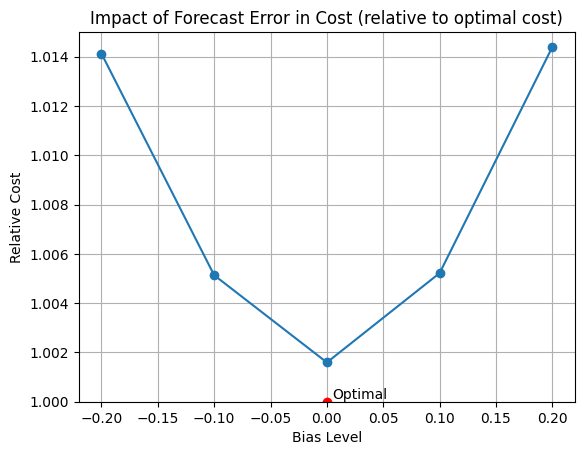

In [81]:
plt.plot(results_bias['bias_level'], results_bias['relative_cost'], marker='o', linestyle='-')

plt.plot(0, 1, 'ro')
plt.text(0.005, 1, 'Optimal', color='black', va='bottom', ha='left')

#plt.axhline(y=1.21, color='red', linestyle='--', linewidth=1)
#plt.text(0, 1.01, '100% on-demand', color='black', va='bottom', ha='center')

plt.xlabel('Bias Level')
plt.ylabel('Relative Cost')
plt.title('Impact of Forecast Error in Cost (relative to optimal cost)')
plt.grid(True)

plt.ylim(1, 1.015)

plt.show()

#### Only SD

In [26]:
results_sd = results[results['bias_level'] == 0]
results_sd = results_sd.sort_values(by=['sd_level'])
results_sd

,bias_level,sd_level,cost,relative_cost
0,0.0,0.0,1.275322e+07,1.001594
7,0.0,0.1,1.275374e+07,1.001635
12,0.0,0.2,1.275853e+07,1.002011


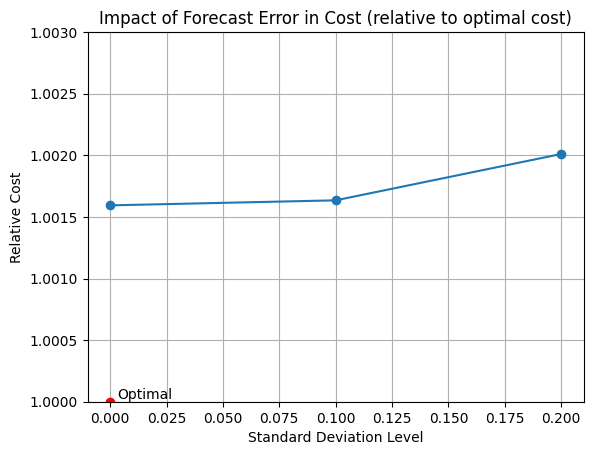

In [49]:
plt.plot(results_sd['sd_level'], results_sd['relative_cost'], marker='o', linestyle='-')

plt.plot(0, 1, 'ro')
plt.text(0.003, 1, 'Optimal', color='black', va='bottom', ha='left')

plt.xlabel('Standard Deviation Level')
plt.ylabel('Relative Cost')
plt.title('Impact of Forecast Error in Cost (relative to optimal cost)')
plt.grid(True)
plt.ylim(1, 1.003)

plt.show()

#### Both

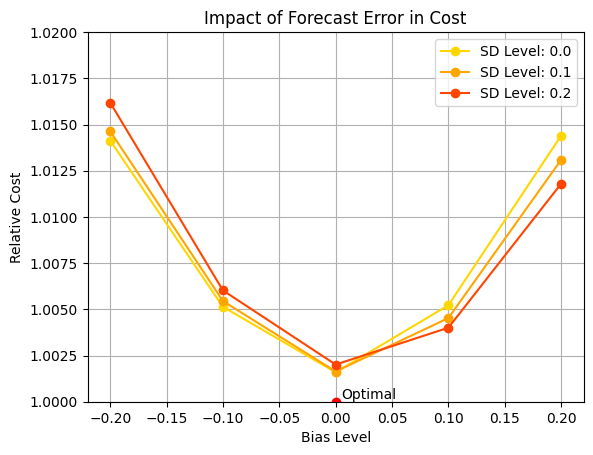

In [ ]:
sd_levels = sorted(list(set(results['sd_level'])))
colors = ['gold', 'orange', 'orangered']

for i in range(len(sd_levels)):
    sd_level = sd_levels[i]
    results_sd_level = results[results['sd_level'] == sd_level]
    results_sd_level = results_sd_level.sort_values(by=['bias_level'])
    plt.plot(results_sd_level['bias_level'], results_sd_level['relative_cost'], marker='o', linestyle='-', label=f'SD Level: {sd_level}', color=colors[i])

plt.plot(0, 1, 'ro')
plt.text(0.005, 1, 'Optimal', color='black', va='bottom', ha='left')

plt.ylim(1, 1.02)
plt.xlabel('Bias Level')
plt.ylabel('Relative Cost')
plt.title('Impact of Forecast Error in Cost')
plt.legend()
plt.grid(True)

plt.show()